In [1]:
# Diagnóstico do ambiente — verificar antes de executar o restante
import sys
from pathlib import Path

print("Python   :", sys.version.split()[0])
print("Executável:", sys.executable)
print("Diretório :", Path.cwd())

# Verificar que o executável pertence ao projeto discover_alelo
exe = sys.executable.lower()
if "discover_alelo" not in exe:
    print()
    print("⚠️  ATENÇÃO: o kernel NÃO pertence ao projeto discover_alelo.")
    print("   Kernel atual:", sys.executable)
    print("   Esperado    : C:\\proj\\discover_alelo\\.venv\\Scripts\\python.exe")
    print()
    print("   Solução:")
    print("   1. Clicar no kernel (canto superior direito do VS Code)")
    print("   2. Select Another Kernel → Python 3.11 — discover_alelo")
    print("   3. Reiniciar o kernel e executar novamente")
else:
    print("✓  Kernel correto — discover_alelo")


Python   : 3.14.2
Executável: C:\proj\discover_alelo\.venv\Scripts\python.exe
Diretório : C:\proj\discover_alelo\notebooks
✓  Kernel correto — discover_alelo


In [2]:
# Configuração — executar primeiro
EXECUTION_MODE = "OFFLINE_EVIDENCE"
# "OFFLINE_EVIDENCE" → lê artefatos do gate. Sem AWS.
# "LIVE_HML"         → requer BEDROCK_KNOWLEDGE_BASE_ID e BEDROCK_MODEL_ID (Passo 9+)

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))  # notebooks/

import json, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from IPython.display import display, HTML

from helpers import (
    load_artifact, mask_sensitive, validate_artifact, check_field_value,
    compute_threshold_metrics, extract_top_scores,
    pass_fail_badge, format_metrics_table, smoke_case_html,
    ARTIFACTS_DIR,
)

# Avisos de matplotlib desativados para output limpo
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

print(f"EXECUTION_MODE = {EXECUTION_MODE}")
print(f"Artefatos em   : {ARTIFACTS_DIR}")
print(f"Artefatos existem: {ARTIFACTS_DIR.exists()}")


EXECUTION_MODE = OFFLINE_EVIDENCE
Artefatos em   : C:\proj\discover_alelo\phase_3_e2e_gate\artifacts
Artefatos existem: True


# Fase 3 — Validação e Demonstração do RAG

**Projeto:** Agente Consultivo MARH — POC Alelo
**Passo:** 8B — Notebook de Validação e Demonstração
**Modo:** Evidências do Gate End-to-End Descartável (Passo 8A)
**Data dos artefatos:** 2026-07-24
**Região AWS:** sa-east-1 (exclusiva)

---

## Resumo executivo

Este notebook valida automaticamente as evidências produzidas pelo gate
end-to-end do Passo 8A e explica a arquitetura RAG para público técnico e
de negócio.

**Resultado:** `GO_PHASE_3_INFRA_WITH_CONDITIONS`

| Componente | Resultado |
|---|---|
| Knowledge Base + S3 Vectors | VALIDATED em sa-east-1 |
| Ingestão do corpus | COMPLETE — 1 documento, 0 falhas |
| Retrieve (14 tópicos + 3 negativos) | Executado com sucesso |
| Threshold recomendado | **0.65** (provisório — Passo 10) |
| Pipeline completo (smoke) | 3 casos validados |
| Teardown | COMPLETE — residual=0 |


## 1. Objetivo da Fase 3

A Fase 3 substitui o `MockKnowledgeClient` por uma implementação real de
conhecimento usando Bedrock e RAG, **exclusivamente** para as intenções
informativas INT-008 a INT-021.

**Isolamento garantido:**

- `DATA_SOURCE_MODE=MOCK` → INT-001 a INT-007 continuam no mock (ma-hr-orch não é chamada)
- `KNOWLEDGE_MODE=BEDROCK_RAG` → INT-008 a INT-021 usam RAG real

**Corpus aprovado:** somente `discover3/knowledge/marh_feature_knowledge.md`

Nenhum dado corporativo (colaboradores, pedidos, CPF) é enviado ao modelo.


## 2. Arquitetura do pipeline RAG

```
Mensagem do usuário
        │
   IntentClassifier
        │
      Router
        │
   flow == "RAG_ONLY"?
        │
   KnowledgeClient.query(topic)
        │
 BedrockRagKnowledgeClient
        │
   topic → query_string (mapeamento fixo — 14 tópicos)
        │
 BedrockKnowledgeBaseRetriever
   bedrock-agent-runtime:Retrieve  ← NÃO usa RetrieveAndGenerate
        │
   list[RetrievedChunk] com scores
        │
   filtragem: score >= RETRIEVAL_SCORE_THRESHOLD
        │
   [sem evidência] ──→ found=False, sem chamada ao LLM
        │
   [com evidência]
        │
 BedrockLanguageModelClient
   bedrock-runtime:Converse  ← permissão IAM: bedrock:InvokeModel
        │
   GenerationResult (texto plano)
        │
   ChatResponse com flow_detail=BEDROCK_RAG
```

**Princípios de segurança:**
- Sem `RetrieveAndGenerate` — Retrieve e geração são etapas separadas
- Texto gerado é plano — nunca tratado como HTML pelo frontend
- Metadata sensível (URIs S3, ARNs, IDs) nunca propagada ao Router


In [3]:
# Carregamento e validação de todos os artefatos
artefatos = {
    "gate_summary":              load_artifact("gate_summary.json"),
    "vector_index_validation":   load_artifact("vector_index_validation.json"),
    "ingestion_result":          load_artifact("ingestion_result.json"),
    "retrieve_scores":           load_artifact("retrieve_scores.json"),
    "threshold_analysis":        load_artifact("threshold_analysis_query_level.json"),
    "threshold_chunk_level":     load_artifact("threshold_comparison_chunk_level.json"),
    "teardown":                  load_artifact("teardown_verification.json"),
}

status_html = ""
for nome, dados in artefatos.items():
    ok = dados is not None
    status_html += f"<li>{pass_fail_badge(ok)} <code>{nome}</code></li>"

display(HTML(f"<h4>Artefatos carregados:</h4><ul>{status_html}</ul>"))

ausentes = [n for n, d in artefatos.items() if d is None]
if ausentes:
    print(f"\n⚠️  Artefatos ausentes: {ausentes}")
    print("Execute o gate (phase_3_e2e_gate/gate_runner.py) para gerar os artefatos.")


## 3. Validação do índice S3 Vectors

In [4]:
idx = artefatos["vector_index_validation"]

if idx is None:
    display(HTML(pass_fail_badge(False, "vector_index_validation.json ausente")))
else:
    erros = validate_artifact(idx, ["status", "dimension", "distance_metric",
                                     "data_type", "non_filterable_metadata_keys"], "vector_index")
    ok_status   = check_field_value(idx, "status", "VALIDATED", "vector_index")
    ok_dim      = check_field_value(idx, "dimension", 1024, "vector_index")
    ok_metric   = check_field_value(idx, "distance_metric", "cosine", "vector_index")
    required_keys = {"AMAZON_BEDROCK_TEXT", "AMAZON_BEDROCK_METADATA"}
    actual_keys   = set(idx.get("non_filterable_metadata_keys", []))
    ok_keys       = None if actual_keys == required_keys else f"Keys incorretas: {actual_keys}"

    checks = [
        ("Status VALIDATED",                ok_status),
        ("Dimensão 1024",                   ok_dim),
        ("Distância cosine",                ok_metric),
        ("nonFilterableMetadataKeys corretas", ok_keys),
    ]
    html = "<div style='color:#111111'><h4>Validação do Vector Index:</h4><ul>"
    all_ok = True
    for label, err in checks:
        passed = err is None
        all_ok = all_ok and passed
        html += f"<li>{pass_fail_badge(passed)} {label}"
        if err:
            html += f" — <code>{err}</code>"
        html += "</li>"
    html += f"</ul><p><b>Resultado geral:</b> {pass_fail_badge(all_ok, 'metadataConfiguration VALIDATED')}</p></div>"
    display(HTML(html))


## 4. Resultado da ingestão

In [5]:
ing = artefatos["ingestion_result"]

if ing is None:
    display(HTML(pass_fail_badge(False, "ingestion_result.json ausente")))
else:
    stats = ing.get("statistics", {})
    ok = ing.get("status") == "COMPLETE"
    html = f"""
    <div style='color:#111111'>
    <h4>Ingestão do corpus:</h4>
    <ul>
      <li>{pass_fail_badge(ok)} Status: <b>{ing.get("status")}</b></li>
      <li>Duração: {ing.get("duration_seconds", "?")} segundos</li>
      <li>Documentos escaneados: {stats.get("numberOfDocumentsScanned", 0)}</li>
      <li>Documentos indexados:  {stats.get("numberOfNewDocumentsIndexed", 0)}</li>
      <li>Documentos com falha:  {stats.get("numberOfDocumentsFailed", 0)}</li>
    </ul>
    </div>
    """
    reasons = ing.get("failure_reasons", [])
    if reasons:
        safe_reasons = [mask_sensitive(r) for r in reasons]
        html += "<p><b>Motivos de falha (sanitizados):</b></p><ul>"
        html += "".join(f"<li><code>{r}</code></li>" for r in safe_reasons)
        html += "</ul>"
    display(HTML(html))


## 5. Retrieve — 14 tópicos positivos e 3 negativos

In [6]:
rs = artefatos["retrieve_scores"]

if rs is None:
    display(HTML(pass_fail_badge(False, "retrieve_scores.json ausente")))
else:
    pos = rs.get("positive_cases", [])
    neg = rs.get("negative_cases", [])

    # Tabela positivos — aspas simples dentro das f-strings (compatível Python 3.11)
    td = "color:#111111;padding:6px 10px"
    td_c = "color:#111111;padding:6px 10px;text-align:center"

    def pos_row(c):
        topic   = c.get("topic", "-")
        results = c.get("results_returned", 0)
        score   = round(c.get("max_score", 0) or 0, 4)
        sources = ", ".join(c.get("source_files") or [])
        return (
            f"<tr style='background:#ffffff'>"
            f"<td style='{td}'>{topic}</td>"
            f"<td style='{td_c}'>{results}</td>"
            f"<td style='{td_c}'>{score}</td>"
            f"<td style='{td}'>{sources}</td></tr>"
        )

    def neg_row(c):
        case_id  = c.get("case_id", "-")
        results  = c.get("results_returned", 0)
        score    = round(c.get("max_score", 0) or 0, 4)
        reaches  = c.get("would_reach_rag_in_real_flow", "N/A")
        return (
            f"<tr style='background:#ffffff'>"
            f"<td style='{td}'>{case_id}</td>"
            f"<td style='{td_c}'>{results}</td>"
            f"<td style='{td_c}'>{score}</td>"
            f"<td style='{td_c}'>{reaches}</td></tr>"
        )

    pos_rows = "".join(pos_row(c) for c in pos)
    neg_rows = "".join(neg_row(c) for c in neg)
    th_style = "background:#2c3e50;color:#ffffff;padding:6px 10px"
    tbl = "border-collapse:collapse;width:100%;background:#ffffff;color:#111111"

    html = (
        f"<h4 style='color:#111111'>Consultas positivas ({len(pos)} tópicos oficiais):</h4>"
        f"<table style='{tbl}'><thead><tr>"
        f"<th style='{th_style}'>Tópico</th>"
        f"<th style='{th_style}'>Resultados</th>"
        f"<th style='{th_style}'>Top Score</th>"
        f"<th style='{th_style}'>Fonte</th>"
        f"</tr></thead><tbody>{pos_rows}</tbody></table><br>"
        f"<h4 style='color:#111111'>Consultas negativas ({len(neg)}):</h4>"
        f"<table style='{tbl}'><thead><tr>"
        f"<th style='{th_style}'>Caso</th>"
        f"<th style='{th_style}'>Resultados</th>"
        f"<th style='{th_style}'>Top Score</th>"
        f"<th style='{th_style}'>Chega ao RAG no fluxo real?</th>"
        f"</tr></thead><tbody>{neg_rows}</tbody></table>"
    )
    display(HTML(html))


Tópico,Resultados,Top Score,Fonte
AGENT_CAPABILITIES,4,0.7169,marh_feature_knowledge.md
CONSULTABLE_INFO,5,0.738,marh_feature_knowledge.md
ORDER_PROCESS,4,0.7727,marh_feature_knowledge.md
HOW_CONSULT_ORDER,4,0.6915,marh_feature_knowledge.md
HOW_CONSULT_COLLABORATOR,5,0.6855,marh_feature_knowledge.md
CARD_TRACKING_INFO,4,0.7541,marh_feature_knowledge.md
CANNOT_CANCEL,5,0.6515,marh_feature_knowledge.md
CANNOT_EDIT_COLLABORATOR,5,0.7057,marh_feature_knowledge.md
COMPANY_SCOPE,4,0.7164,marh_feature_knowledge.md
COMPANY_REQUIRED,4,0.6714,marh_feature_knowledge.md


## 6. Análise query-level do threshold

In [7]:
ta = artefatos["threshold_analysis"]
rs = artefatos["retrieve_scores"]

if ta is None or rs is None:
    display(HTML(pass_fail_badge(False, "Artefatos de threshold ausentes")))
else:
    pos_tops, neg_tops = extract_top_scores(rs)
    thresholds = [0.50, 0.60, 0.65, 0.70, 0.75, 0.80]
    rows = compute_threshold_metrics(pos_tops, neg_tops, thresholds)

    display(HTML("<h4>Métricas por threshold (unidade: consulta, top_score = max dos chunks):</h4>"))
    display(HTML(format_metrics_table(rows, highlight_threshold=0.65)))
    display(HTML(
        "<p><b>Linha destacada</b> = recomendação provisória "
        "<code>RETRIEVAL_SCORE_THRESHOLD=0.65</code></p>"
    ))


threshold,TP,FN,TN,FP,recall,F1,balanced_accuracy
0.5,14,0,0,3,1.0,0.9032,0.5
0.6,14,0,1,2,1.0,0.9333,0.6667
0.65,14,0,2,1,1.0,0.9655,0.8333
0.7,6,8,2,1,0.4286,0.5714,0.5476
0.75,2,12,3,0,0.1429,0.25,0.5714
0.8,0,14,3,0,0.0,0.0,0.5


## 7. Gráficos de métricas por threshold

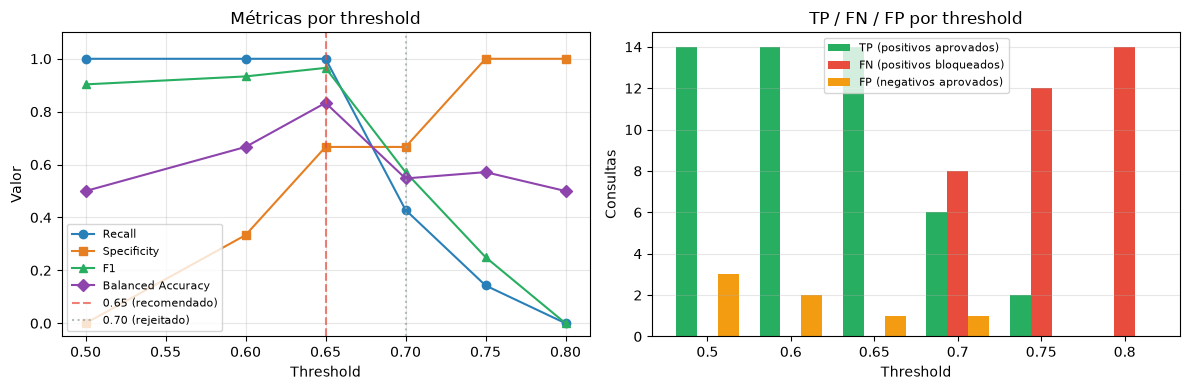

Gráfico salvo em reports/threshold_metrics.png


In [8]:
rs = artefatos["retrieve_scores"]
if rs is None:
    print("retrieve_scores.json ausente — gráficos indisponíveis")
else:
    pos_tops, neg_tops = extract_top_scores(rs)
    thresholds = [0.50, 0.60, 0.65, 0.70, 0.75, 0.80]
    rows = compute_threshold_metrics(pos_tops, neg_tops, thresholds)

    ts   = [r["threshold"] for r in rows]
    rec  = [r["recall"] for r in rows]
    spe  = [r["specificity"] for r in rows]
    f1   = [r["F1"] for r in rows]
    bal  = [r["balanced_accuracy"] for r in rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax1 = axes[0]
    ax1.plot(ts, rec, "o-", color="#2980b9", label="Recall")
    ax1.plot(ts, spe, "s-", color="#e67e22", label="Specificity")
    ax1.plot(ts, f1,  "^-", color="#27ae60", label="F1")
    ax1.plot(ts, bal, "D-", color="#8e44ad", label="Balanced Accuracy")
    ax1.axvline(x=0.65, color="#e74c3c", linestyle="--", alpha=0.7, label="0.65 (recomendado)")
    ax1.axvline(x=0.70, color="#95a5a6", linestyle=":",  alpha=0.7, label="0.70 (rejeitado)")
    ax1.set_xlabel("Threshold")
    ax1.set_ylabel("Valor")
    ax1.set_title("Métricas por threshold")
    ax1.set_ylim(-0.05, 1.1)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    # TP/FN por threshold
    ax2 = axes[1]
    tp_vals = [r["TP"] for r in rows]
    fn_vals = [r["FN"] for r in rows]
    fp_vals = [r["FP"] for r in rows]
    x = range(len(ts))
    width = 0.25
    ax2.bar([i - width for i in x], tp_vals, width, label="TP (positivos aprovados)", color="#27ae60")
    ax2.bar(x,                       fn_vals, width, label="FN (positivos bloqueados)", color="#e74c3c")
    ax2.bar([i + width for i in x],  fp_vals, width, label="FP (negativos aprovados)", color="#f39c12")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels([str(t) for t in ts])
    ax2.set_xlabel("Threshold")
    ax2.set_ylabel("Consultas")
    ax2.set_title("TP / FN / FP por threshold")
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("../reports/threshold_metrics.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Gráfico salvo em reports/threshold_metrics.png")


## 8. Por que 0.65 foi escolhido

| Threshold | Problema |
|---|---|
| 0.50 | Aceita todas as negativas (FP=3) — sem discriminação |
| 0.60 | FP=2 — ainda ruído excessivo |
| **0.65** | **TP=14, FN=0, FP=1 — recall=1.0, F1=0.966** ← recomendado |
| 0.70 | FN=8 — bloqueia 57% dos tópicos válidos. **Inaceitável para POC.** |
| 0.75–0.80 | Quase nenhum tópico aprovado |

**Sobre o único FP em 0.65 — NEG-003:**

A pergunta *"Qual é o CNPJ da Alelo?"* retorna `top_score=0.724` no Retrieve isolado.
No entanto, **esta pergunta nunca chega ao KnowledgeClient no fluxo real** — o Router
a classifica como `STATIC_RESPONSE` (ERR-008) antes de qualquer consulta ao RAG.

O falso positivo existe no componente `BedrockKnowledgeBaseRetriever` de forma isolada,
mas é inativo no pipeline completo.

**Status:** `THRESHOLD_STATUS=PROVISIONAL_PENDING_DATASET_EVALUATION`
Calibração definitiva ocorre no Passo 10 com o dataset completo de 20 casos.


## 9. Smoke do pipeline completo

In [9]:
sm = artefatos["pipeline_smoke"] if "pipeline_smoke" in artefatos else load_artifact("pipeline_smoke.json")

if sm is None:
    display(HTML(pass_fail_badge(False, "pipeline_smoke.json ausente")))
else:
    threshold_usado = sm.get("score_threshold_used", "?")
    model_temp = sm.get("temporary_model", "?")
    display(HTML(
        f"<p style='color:#111111'><b>Threshold usado:</b> {threshold_usado} &nbsp; "
        f"<b>Modelo temporário:</b> <code>{model_temp}</code> "
        f"(não é o modelo definitivo — seleção no Passo 10)</p>"
    ))
    for case in sm.get("results", []):
        display(HTML(smoke_case_html(case)))

    # Validações gerais
    results = sm.get("results", [])
    caso1 = next((r for r in results if r.get("topic") == "MARH_OVERVIEW"), None)
    caso2 = next((r for r in results if not r.get("found") and r.get("reason") == "topic_unknown"), None)
    caso3 = next((r for r in results if r.get("topic") == "ORDER_PROCESS"), None)

    checks = [
        ("MARH_OVERVIEW found=True",                  caso1 and caso1.get("found") is True),
        ("MARH_OVERVIEW flow_detail=BEDROCK_RAG",     caso1 and caso1.get("flow_detail") == "BEDROCK_RAG"),
        ("Tópico desconhecido found=False",           caso2 is not None),
        ("Tópico desconhecido reason=topic_unknown",  caso2 and caso2.get("reason") == "topic_unknown"),
        ("ORDER_PROCESS found=True",                   caso3 and caso3.get("found") is True),
        ("ORDER_PROCESS approved_chunks>=1",           caso3 and (caso3.get("approved_chunks") or 0) >= 1),
    ]
    html = "<div style='color:#111111'><h4>Validações do smoke:</h4><ul>"
    all_ok = True
    for label, ok in checks:
        all_ok = all_ok and bool(ok)
        html += f"<li>{pass_fail_badge(bool(ok))} {label}</li>"
    html += f"</ul><p><b>Smoke:</b> {pass_fail_badge(all_ok, 'PASSOU' if all_ok else 'FALHOU')}</p></div>"
    display(HTML(html))


## 10. Auditoria do NEG-003

**Pergunta:** *"Qual é o CNPJ da Alelo?"*
**Top score no Retrieve isolado:** 0.724 (acima de 0.65 e de 0.70)
**Classificação esperada:** `OUT_OF_CORPUS`

### Por que essa pergunta recupera chunks com score alto?

O corpus `marh_feature_knowledge.md` contém diversas referências à empresa Alelo
e ao Espaço RH. O modelo de embedding encontra similaridade semântica entre
*"CNPJ da Alelo"* e textos sobre *"empresa"* e *"Alelo"* no corpus — mesmo que
o conteúdo não responda à pergunta.

### Por que isso não é um problema no fluxo real?

O Router classifica a intenção antes de consultar o KnowledgeClient.
A pergunta sobre CNPJ não corresponde a nenhuma das intenções INT-008 a INT-021
(intenções informativas do MARH) — o Router retornaria `ERR-008 (STATIC_RESPONSE)`
antes de qualquer consulta RAG.

**Status:** `NEG_003_STATUS=FALSE_POSITIVE_IN_ISOLATED_RETRIEVE_BLOCKED_BY_ROUTER`

### Implicação para calibração

O FP do NEG-003 é estrutural no Retrieve, mas inativo no pipeline. Ainda assim,
ao ampliar o corpus no futuro, é recomendável monitorar se perguntas sobre dados
cadastrais da empresa continuam produzindo scores altos.


## 11. Teardown — recursos destruídos

In [10]:
td = artefatos["teardown"]

if td is None:
    display(HTML(pass_fail_badge(False, "teardown_verification.json ausente")))
else:
    ok = td.get("status") == "COMPLETE" and td.get("residual", 1) == 0
    actions = td.get("actions", [])
    errors  = td.get("errors", [])
    html = f"""
    <div style='color:#111111'>
    <h4>Teardown:</h4>
    <ul>
      <li>{pass_fail_badge(ok)} Status: <b>{td.get("status")}</b></li>
      <li>Recursos destruídos: {len(actions)}</li>
      <li>Erros: {len(errors)}</li>
      <li>Residuais: <b>{td.get("residual", "?")}</b></li>
    </ul>
    </div>
    """
    if actions:
        html += "<div style='color:#111111'><p><b>Ações executadas:</b></p><ul>"
        html += "".join(f"<li><code>{a}</code></li>" for a in actions)
        html += "</ul></div>"
    display(HTML(html))


## 12. Condições e limitações

| Item | Status |
|---|---|
| `RETRIEVAL_SCORE_THRESHOLD` | `0.65 — PROVISIONAL_PENDING_DATASET_EVALUATION` |
| Modelo de geração | `PROPOSED_PENDING_DATASET_EVALUATION` — Passo 10 |
| NEG-003 | FP isolado, inativo no pipeline real |
| Corpus | Apenas `marh_feature_knowledge.md` (PENDING_CLIENT_APPROVAL) |
| `COST_ESTIMATE_STATUS` | `PENDING_MODEL_AND_PERMANENT_INFRA_SELECTION` |
| Knowledge Base permanente | Não criada — gate usou recursos descartáveis |
| Cross-region | Proibido — todos os componentes em sa-east-1 |


## 13. Próximos passos — RAG HML

### Passo 9 — Terraform do ambiente permanente

- Lambda `marh-agent-rag-hml`
- Knowledge Base permanente com S3 Vectors em sa-east-1
- API Gateway e CloudFront dedicados
- Badge `AWS RAG HML` no frontend
- Secrets Manager: `BEDROCK_KNOWLEDGE_BASE_ID`, `BEDROCK_MODEL_ID`
- `RETRIEVAL_SCORE_THRESHOLD=0.65` (provisório)

### Passo 10 — Dataset de avaliação e seleção do modelo

- Executar os 20 casos do dataset oficial (INT-008 a INT-021 + negativos)
- Calibrar threshold com o dataset maior
- Comparar candidatos de geração (Mistral Large, Magistral Small, Gemma 27B, Qwen 32B)
- Selecionar modelo definitivo — excluídos: Haiku, Sonnet v1
- Emitir `RETRIEVAL_SCORE_THRESHOLD_FINAL` e `GENERATION_MODEL_FINAL`

### Modo LIVE_HML (disponível após Passo 9)

```python
# Para ativar:
EXECUTION_MODE = "LIVE_HML"
# Requer variáveis de ambiente:
# BEDROCK_KNOWLEDGE_BASE_ID=<id permanente>
# BEDROCK_MODEL_ID=<modelo selecionado>
# BEDROCK_REGION=sa-east-1
# RETRIEVAL_SCORE_THRESHOLD=0.65
```


## 14. Apêndice técnico

### Componentes implementados (Passos 2–7)

| Componente | Arquivo | Responsabilidade |
|---|---|---|
| `DataSourceMode`, `KnowledgeMode` | `config.py` | Eixos ortogonais de configuração |
| `RetrievedChunk`, `GenerationResult` | `domain/rag_models.py` | Modelos internos (sem boto3) |
| `Retriever` | `clients/retriever.py` | Interface de recuperação vetorial |
| `LanguageModelClient` | `clients/language_model_client.py` | Interface de geração |
| `BedrockRagKnowledgeClient` | `clients/bedrock_rag_knowledge_client.py` | Orquestrador do pipeline |
| `BedrockKnowledgeBaseRetriever` | `clients/bedrock_knowledge_base_retriever.py` | Retrieve real via AWS |
| `BedrockLanguageModelClient` | `clients/bedrock_language_model_client.py` | Converse real via AWS |
| `knowledge_client_factory` | `application/knowledge_client_factory.py` | Composition root |

### Testes

- **399 testes** no backend — todos passando, zero chamadas AWS durante pytest
- **59 testes** no gate (helpers, Stubber, análise de threshold)
- **38 testes** neste notebook (`notebooks/tests/test_helpers.py`)

### Corpus aprovado

`discover3/knowledge/marh_feature_knowledge.md`
sha256: `5f7b9dfa...` (11.751 bytes)

Não incluído no RAG: dados da ma-hr-orch, pedidos, colaboradores, CPF,
rotas, deeplinks, schemas de API, decisões de infraestrutura.
